# 7. KMeans Clustering with Scikit-Learn and MLlib

Implement the K-Means Algorithm using Scikit-Learn and MLlib!

In [1]:
!pip install -q pyspark

In [2]:
%matplotlib inline
from sklearn import datasets
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

The dataset class provides access to different public datasets. It will return a scikit-learn bunch: <https://scikit-learn.org/stable/datasets/index.html>

In [3]:
iris = datasets.load_iris()

Convert Scikit Bunch to Pandas Dataframe

In [4]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 7.1 Cluster the data using the KMeans implementation of scikit-learn

* Resource: <https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_iris.html>
* Measure the runtime for training the model.
* Experiment with different numbers of clusters. What are your observations?
* Plot the results.

In [5]:
# Task 7.1 Cluster the data using the KMeans
# k=2
print("Task 7.1 Cluster the data using the KMeans")
import time
from sklearn.cluster import KMeans

# Use feature data
X = iris_df[['sepal length (cm)', 'sepal width (cm)',
             'petal length (cm)', 'petal width (cm)']]

print("To check data shape:")
print (X)

# Measure runtime
# Start timing
start_time = time.time()

# Train KMeans model
# According to the documentation, n_init='auto' automatically selects an appropriate number of initializations.
# Since I'm ot sure if this value vary or not, I explicitly set n_init=10 to keep it fixed.
# This ensures that any changes in the results are due only to the variation in n_clusters.
kmeans = KMeans(n_clusters=2, random_state=100, n_init=10)
kmeans.fit(X)

# End timing
end_time = time.time()
# Compute runtime
runtime = end_time - start_time

print("Training runtime with 2 clusters: ", runtime, "seconds")


Task 7.1 Cluster the data using the KMeans
To check data shape:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8


Training runtime with 2 clusters: 0.013356208801269531 seconds
Training runtime with 3 clusters: 0.013643264770507812 seconds
Training runtime with 4 clusters: 0.014626741409301758 seconds
Training runtime with 5 clusters: 0.014710426330566406 seconds
Training runtime with 6 clusters: 0.016842365264892578 seconds
Training runtime with 7 clusters: 0.018175840377807617 seconds
Training runtime with 8 clusters: 0.02020716667175293 seconds
Training runtime with 9 clusters: 0.021976947784423828 seconds
Training runtime with 10 clusters: 0.023304224014282227 seconds
Training runtime with 11 clusters: 0.02556157112121582 seconds
Training runtime with 12 clusters: 0.027341604232788086 seconds


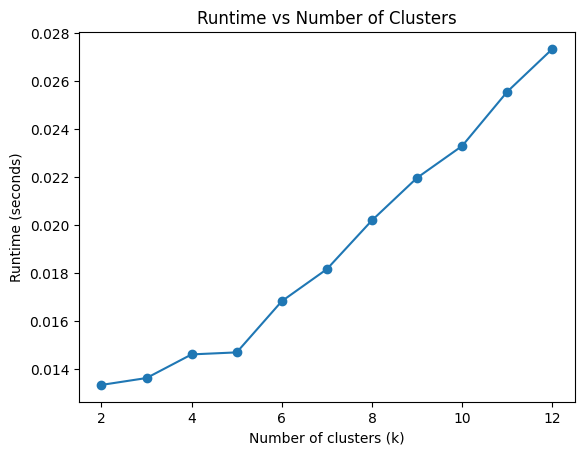

In [6]:
import time
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = [2,3,4,5,6,7,8,9,10,11,12]
runtimes = []


for k in k_values:
    start_time = time.time()

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    end_time = time.time()
    print("Training runtime with",k,"clusters:",(end_time - start_time), "seconds")

    runtimes.append(end_time - start_time)

# Plot
plt.plot(k_values, runtimes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Number of Clusters")
plt.show()

## 7.2 Manual KMeans Clustering

Implement KMeans clustering using the Spark RDD API (do **not** use the MLlib KMeans implementation).

* Use the Iris dataset as input.
* Implement the iterative assignment and update steps using `map` and `reduceByKey`.
* Run until convergence or for a fixed number of iterations (e.g. 20).
* Compare your results to the scikit-learn KMeans output from 7.1.

In [38]:
# based on Spark repo: https://github.com/apache/spark/blob/master/examples/src/main/python/kmeans.py
print("Task 7.2: KMeans clustering using the Spark RDD API ")
# 1. Start Spark
from pyspark.sql import SparkSession
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

Task 7.2: KMeans clustering using the Spark RDD API 


In [39]:
# 1. Start Spark
spark = SparkSession.builder.appName("ManualKMeansRDD").getOrCreate()
sc = spark.sparkContext


In [40]:
# Distribute the data across Spark workers
df_rdd = iris.data
data_rdd = sc.parallelize(df_rdd).map(lambda row: np.array(row))
# print to check
print("Total points in RDD:", data_rdd.count())
print(data_rdd.collect())


Total points in RDD: 150
[array([5.1, 3.5, 1.4, 0.2]), array([4.9, 3. , 1.4, 0.2]), array([4.7, 3.2, 1.3, 0.2]), array([4.6, 3.1, 1.5, 0.2]), array([5. , 3.6, 1.4, 0.2]), array([5.4, 3.9, 1.7, 0.4]), array([4.6, 3.4, 1.4, 0.3]), array([5. , 3.4, 1.5, 0.2]), array([4.4, 2.9, 1.4, 0.2]), array([4.9, 3.1, 1.5, 0.1]), array([5.4, 3.7, 1.5, 0.2]), array([4.8, 3.4, 1.6, 0.2]), array([4.8, 3. , 1.4, 0.1]), array([4.3, 3. , 1.1, 0.1]), array([5.8, 4. , 1.2, 0.2]), array([5.7, 4.4, 1.5, 0.4]), array([5.4, 3.9, 1.3, 0.4]), array([5.1, 3.5, 1.4, 0.3]), array([5.7, 3.8, 1.7, 0.3]), array([5.1, 3.8, 1.5, 0.3]), array([5.4, 3.4, 1.7, 0.2]), array([5.1, 3.7, 1.5, 0.4]), array([4.6, 3.6, 1. , 0.2]), array([5.1, 3.3, 1.7, 0.5]), array([4.8, 3.4, 1.9, 0.2]), array([5. , 3. , 1.6, 0.2]), array([5. , 3.4, 1.6, 0.4]), array([5.2, 3.5, 1.5, 0.2]), array([5.2, 3.4, 1.4, 0.2]), array([4.7, 3.2, 1.6, 0.2]), array([4.8, 3.1, 1.6, 0.2]), array([5.4, 3.4, 1.5, 0.4]), array([5.2, 4.1, 1.5, 0.1]), array([5.5, 4.2, 

In [41]:
# Helper function
def closest_point(point, centers):
    """Return the index of the nearest center."""
    best_index = 0
    best_dist = float("inf")
    for i, center in enumerate(centers):
        dist = np.sum((point - center) ** 2)  # squared Euclidean
        if dist < best_dist:
            best_dist = dist
            best_index = i
    return best_index

In [49]:
# Initialise centroids
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]         # number of clusters
MAX_ITERS = 20  # same as task requirement
CONV_DIST = 1e-4  # convergence threshold
runtimes_spark = []
results = {}

# Pick K random points as starting centroids (like the GitHub example)
centroids = kPoints = data_rdd.takeSample(False, K, 1)
tempDist = 1.0

print("Initial centroids:")
for i, c in enumerate(centroids):
    print(f"  Centroid {i}: {np.round(c, 3)}")

Initial centroids:
  Centroid 0: [5.7 2.8 4.1 1.3]
  Centroid 1: [6.9 3.1 5.4 2.1]


In [50]:

for K in k_values:

    # Init centroids
    kPoints = data_rdd.takeSample(False, K, 1)
    tempDist = 1.0
    start_time = time.time()
    for i in range(MAX_ITERS):
      # --- assignement step ---
      # map: each point → (nearest_centroid_index, (point, 1))

        closest = data_rdd.map(
            lambda p: (closest_point(p, kPoints), (p, 1))
        )

        # update
        # reduceByKey: sum up all points and counts per cluster
        cluster_stats = closest.reduceByKey(
            lambda a, b: (a[0] + b[0], a[1] + b[1])
        )
        # Compute new centroid = sum of points / count

        new_points = cluster_stats.map(
            lambda x: (x[0], x[1][0] / x[1][1])
        ).collectAsMap()

        # Convergence check

        tempDist = sum(
            np.sum((new_points[j] - kPoints[j]) ** 2)
            for j in range(K)
        )

        print(f"Iteration {i+1:2d}  |  tempDist = {tempDist:.6f}")

        # Update centroids
        kPoints = [new_points[j] for j in range(K)]

        if tempDist < 1e-4:
            print(f"\n✓ Converged after {i+1} iterations!")
            break
 # Save runtime and labels
    runtime = time.time() - start_time
    runtimes_spark.append(runtime)

    labels = data_rdd.map(
        lambda p: closest_point(p, kPoints)).collect()
    results[K] = np.array(labels)

    print(f"K={K:2d}  |  runtime={runtime:.4f}s")


Iteration  1  |  tempDist = 1.815475
Iteration  2  |  tempDist = 0.716006
Iteration  3  |  tempDist = 0.382196
Iteration  4  |  tempDist = 0.072701
Iteration  5  |  tempDist = 0.002659
Iteration  6  |  tempDist = 0.000000

✓ Converged after 6 iterations!
K= 2  |  runtime=4.4905s
Iteration  1  |  tempDist = 0.279673
Iteration  2  |  tempDist = 0.006114
Iteration  3  |  tempDist = 0.006381
Iteration  4  |  tempDist = 0.003177
Iteration  5  |  tempDist = 0.000000

✓ Converged after 5 iterations!
K= 3  |  runtime=3.7243s
Iteration  1  |  tempDist = 0.647863
Iteration  2  |  tempDist = 0.081532
Iteration  3  |  tempDist = 0.021599
Iteration  4  |  tempDist = 0.006887
Iteration  5  |  tempDist = 0.014418
Iteration  6  |  tempDist = 0.001107
Iteration  7  |  tempDist = 0.004437
Iteration  8  |  tempDist = 0.000000

✓ Converged after 8 iterations!
K= 4  |  runtime=4.5047s
Iteration  1  |  tempDist = 7.102823
Iteration  2  |  tempDist = 2.175721
Iteration  3  |  tempDist = 0.168309
Iteration  4

In [51]:
# Get final labels
spark_labels = data_rdd.map(
    lambda p: closest_point(p, centroids)
).collect()

spark_labels = np.array(spark_labels)
print("Cluster label counts:", np.bincount(spark_labels))

Cluster label counts: [103  47]


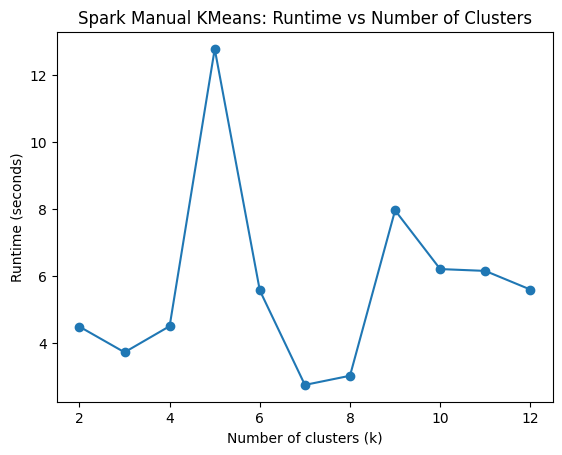

In [53]:
# runtime plot
plt.plot(k_values, runtimes_spark, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Runtime (seconds)")
plt.title("Spark Manual KMeans: Runtime vs Number of Clusters")
plt.show()